In [3]:
import pandas as pd

salinity_df = pd.read_csv("/home/onyxia/work/Stat-App-Montee-des-oceans/my_data_folder/salinity_folder/BDD_salinite.csv", parse_dates=['time'])
sea_level_df = pd.read_csv("/home/onyxia/work/Stat-App-Montee-des-oceans/my_data_folder/sea_level_folder/sea_level_monthly/sea_level_monthly.csv", parse_dates=['time'])
salinity_df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/home/onyxia/work/Stat-App-Montee-des-oceans/my_data_folder/salinity_folder/BDD_salinite.csv'

In [7]:
print("Salinity dates:", salinity_df['time'].min(), "→", salinity_df['time'].max())
print("Sea level dates:", sea_level_df['time'].min(), "→", sea_level_df['time'].max())


Salinity dates: 2010-01-01 00:00:00 → 2023-12-01 00:00:00
Sea level dates: 1993-01-16 00:00:00 → 2023-06-04 00:00:00


In [8]:
salinity_df['year'] = salinity_df['time'].dt.year
salinity_df['month'] = salinity_df['time'].dt.month

sea_level_df['year'] = sea_level_df['time'].dt.year
sea_level_df['month'] = sea_level_df['time'].dt.month


In [9]:
salinity_monthly = salinity_df.groupby(['year', 'month']).mean().reset_index()
sea_level_monthly = sea_level_df.groupby(['year', 'month']).mean().reset_index()


In [11]:
merged_df = pd.merge(salinity_monthly, sea_level_monthly, on=['year', 'month'], how='inner')
merged_df.head()

,year,month,time_x,moyenne_variable,time_y,MSL_filtered_GIA_TPA_corrected_adjusted,trend_MSL_filtered_GIA_TPA_corrected_adjusted
0,2010,1,2010-01-01,34.692608,2010-01-16 00:00:00,13.668426,6.133828
1,2010,2,2010-02-01,34.678696,2010-02-14 12:00:00,13.412240,6.154386
2,2010,3,2010-03-01,34.702680,2010-03-16 00:00:00,11.343056,6.174953
3,2010,4,2010-04-01,34.704070,2010-04-15 12:00:00,8.935583,6.196227
4,2010,5,2010-05-01,34.729305,2010-05-16 00:00:00,7.603814,6.217511


Pente (coefficient): -2.0811
Ordonnée à l'origine: 80.0901
Score R²: 0.0071


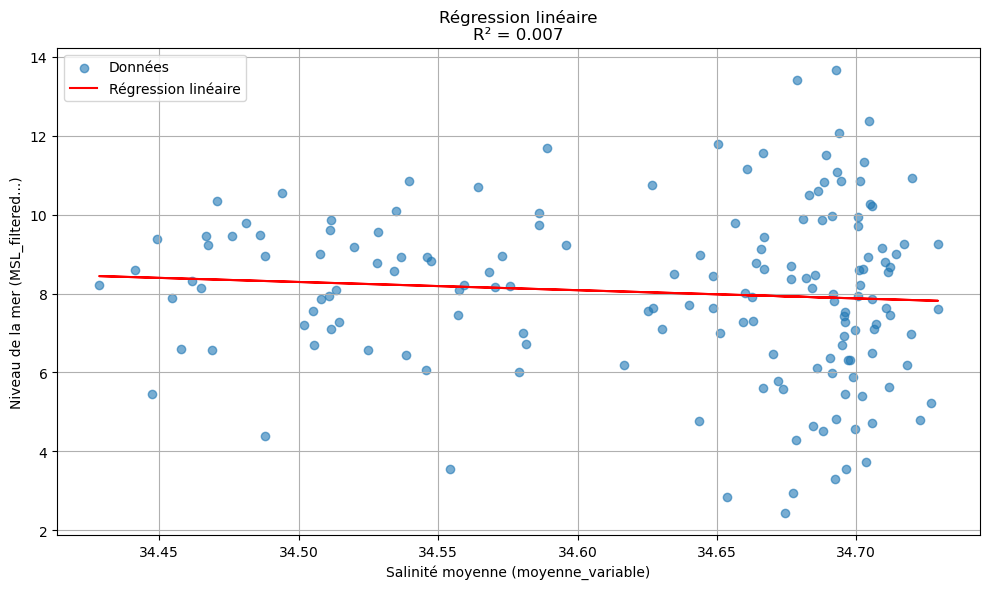

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Préparation des données
df = merged_df[['moyenne_variable', 'MSL_filtered_GIA_TPA_corrected_adjusted']].dropna()
X = df[['moyenne_variable']].values
y = df['MSL_filtered_GIA_TPA_corrected_adjusted'].values

# Modèle
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Statistiques
coef = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

print(f"Pente (coefficient): {coef:.4f}")
print(f"Ordonnée à l'origine: {intercept:.4f}")
print(f"Score R²: {r2:.4f}")

# Graphique
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Données')
plt.plot(X, y_pred, color='red', label='Régression linéaire')
plt.xlabel('Salinité moyenne (moyenne_variable)')
plt.ylabel('Niveau de la mer (MSL_filtered...)')
plt.title(f"Régression linéaire\nR² = {r2:.3f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
